# Part 1: SVM Classification


## Task 1: Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

## Task 2: Load the Dataset


In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df.shape

(569, 30)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## Task 3: Data Exploration


In [7]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [8]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [9]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

target
1    357
0    212
Name: count, dtype: int64


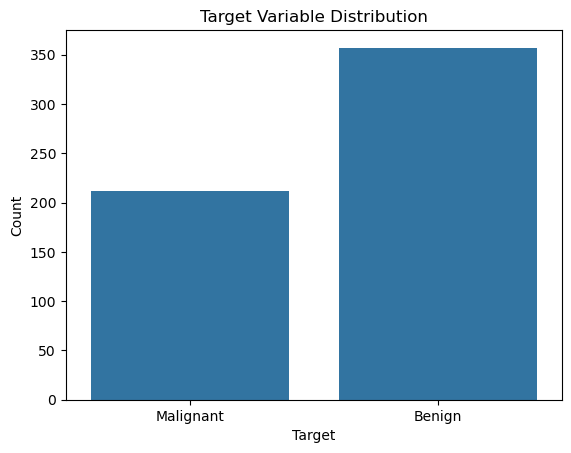

In [10]:
df['target'] = data.target

# Count target values
print(df['target'].value_counts())

# Visualize target distribution
sns.countplot(x='target', data=df)

plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

# Optional class labels
plt.xticks([0, 1], ['Malignant', 'Benign'])

plt.show()

In [11]:
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

## Task 4: Feature and Target Separation


In [12]:
X = df.drop('target', axis=1)
y = df['target']

## Task 5: Train-Test Split


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Task 6: Feature Scaling


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


## Task 7: Train an SVM Classifier

In [15]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
y_pred = svm_model.predict(X_test_scaled)

## Task 8: Model Prediction


In [17]:
y_pred = svm_model.predict(X_test_scaled)
print(y_pred)

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


## Task 9: Model Evaluation


In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score:
0.956140350877193

Confusion Matrix:
[[41  2]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Task 10: Experiment with Different Kernels


In [19]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)


In [20]:
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)


In [21]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

In [22]:
linear_acc = accuracy_score(y_test, y_pred_linear)
poly_acc = accuracy_score(y_test, y_pred_poly)
rbf_acc = accuracy_score(y_test, y_pred_rbf)


In [23]:
comparison = pd.DataFrame({
    'Kernel': ['Linear', 'Polynomial', 'RBF'],
    'Accuracy': [linear_acc, poly_acc, rbf_acc]
})

print(comparison)

       Kernel  Accuracy
0      Linear  0.956140
1  Polynomial  0.868421
2         RBF  0.982456


# Part 2: SVM Regression (SVR)


## Task 1: Load the Dataset


In [24]:
from sklearn.datasets import fetch_openml
import warnings

warnings.filterwarnings("ignore")
california= fetch_openml(name="california_housing", as_frame=True)

df = california.frame


In [25]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


## Task 2: Data Preprocessing


In [27]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [28]:
X.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [29]:
X['total_bedrooms'] = X['total_bedrooms'].fillna(
    X['total_bedrooms'].mean()
)

In [30]:
X.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20640 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(4), int64(4)
memory usage: 1.3 MB


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
ct=ColumnTransformer(transformers=[("oe",OrdinalEncoder(),[8]),
                                   ("sc",StandardScaler(),[0,1,2,3,4,5,6,7])])


In [34]:
x_train_transform=ct.fit_transform(X_train)
x_tarin_transorm=pd.DataFrame(x_train_transform)

In [35]:
x_test_transform=ct.transform(X_test)
x_test_transform=pd.DataFrame(x_test_transform)

## Task 3: Train an SVR Model


In [36]:
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')

svr_linear.fit(x_train_transform, y_train)


,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [37]:
y_pred_ = svr_linear.predict(x_test_transform)

In [40]:
svr_rbf = SVR(kernel='rbf')

# Train model
svr_rbf.fit(x_train_transform, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [41]:
# Predictions
y_pred_rbf = svr_rbf.predict(x_test_transform)

## Task 4: Model Prediction


## Task 5: Model Evaluation

In [45]:
# Import SVR
from sklearn.svm import SVR

# Create Linear SVR model
svr_linear = SVR(kernel='linear')

# Train model
svr_linear.fit(x_train_transform, y_train)

# Generate predictions
y_pred_linear = svr_linear.predict(x_test_transform)

# Verify shapes
print(y_test.shape)
print(y_pred_linear.shape)

(4128,)
(4128,)


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("LINEAR SVR PERFORMANCE")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("R² Score :", r2_linear)

LINEAR SVR PERFORMANCE
MAE : 82421.28859612881
MSE : 12324361577.27683
R² Score : 0.05950266047313557


## Part 3: Hyperparameter Tuning


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Create model
svr = SVR()

# Parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid_search.fit(x_train_transform, y_train)

# Best parameters
print(grid_search.best_params_)

# Best score
print(grid_search.best_score_)

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
0.42859495750909166


# Part 4: Interview-Oriented Theoretical Questions


### 1.What is a Support Vector Machine (SVM)?
##### SVM is a supervised machine learning algorithm used for classification and regression. It finds the best boundary (hyperplane) that separates data points into classes.

### 2.What is a hyperplane in SVM?
##### A hyperplane is the decision boundary that separates different classes in the dataset. In 2D, it is a line; in 3D, it is a plane.

### 3.What are support vectors?
##### Support vectors are the data points closest to the hyperplane. They are critical because they determine the position of the decision boundary.

### 4.What is margin in SVM?
##### Margin is the distance between the hyperplane and the nearest data points from both classes. SVM tries to maximize this margin for better generalization.

### 5.What is the difference between hard margin and soft margin SVM?
##### Hard margin SVM assumes perfectly separable data with no errors. Soft margin allows some misclassifications to handle noisy or overlapping data.

### 6.What is the role of the C parameter in SVM?
##### The C parameter controls the tradeoff between maximizing margin and minimizing classification errors. Large C tries to classify all points correctly, while small C allows more errors.

### 7.Why is feature scaling important in SVM?
##### SVM uses distance calculations, so features with large values can dominate the model. Scaling ensures all features contribute equally.

### 8.What is the kernel trick?
##### The kernel trick transforms data into higher dimensions without explicitly computing coordinates. It helps SVM solve non-linear problems efficiently.

### 9.Explain different types of kernels used in SVM.
##### Common kernels are Linear, Polynomial, RBF, and Sigmoid. Linear works for simple data, while RBF handles complex non-linear relationships.

### 10.What is the RBF kernel?
##### RBF (Radial Basis Function) kernel maps data into higher dimensions to create non-linear decision boundaries. It is the most commonly used SVM kernel.

### 11.What does the gamma parameter control?
##### Gamma controls how much influence a single training point has. High gamma creates complex boundaries, while low gamma creates smoother boundaries.

### 12.What is the difference between SVM classifier and SVR?
##### SVM classifier predicts discrete classes, while SVR (Support Vector Regression) predicts continuous numerical values.

### 13.What loss function is used in SVM?
##### SVM mainly uses the hinge loss function. It penalizes points that are incorrectly classified or too close to the boundary.

### 14.What is hinge loss?
##### Hinge loss measures classification error in SVM. It encourages correct classification with a sufficient margin from the hyperplane.

### 15.What are advantages of SVM?
##### SVM works well in high-dimensional datasets and handles non-linear data using kernels. It is effective even with small datasets.

### 16.What are limitations of SVM?
##### SVM can be slow on large datasets and sensitive to parameter tuning. It also becomes difficult to interpret compared to simpler models.

### 17.When should we use SVM instead of other algorithms?
##### Use SVM when the dataset is small-to-medium sized and features are high-dimensional. It is especially strong for text classification and image recognition.

### 18.What happens when the C value is very large or very small?
##### Large C may overfit by forcing correct classification of training data. Small C creates a wider margin but may underfit

### 19.What is the difference between Logistic Regression and SVM?
##### Logistic Regression predicts probabilities, while SVM focuses on maximizing margin. SVM often performs better on complex boundaries

### 20.Why is SVM effective in high-dimensional datasets?
##### SVM depends mainly on support vectors rather than all data points. This makes it effective when the number of features is very large.